# Modelo com Rebalanceamento e Custos de Transação 

In [1]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
basedados_ativos = Path('../../base_dados/retornos_ativos_2015_2026.csv') 
basedados_ibov = Path('../../base_dados/retorno_ibov_2015_2026.csv') 

lista_magic_formula = []

for filename in os.listdir(path='../../base_dados/brapi/magic_formula/'):
    
    # 2. Reconstruct the full absolute or relative path to the file
    full_path = os.path.join('../../base_dados/brapi/magic_formula/', filename)
    
    # 3. Check if the current item is actually a file (and not a subfolder)
    # if os.path.isfile(full_path):
        
    #     # 4. Open and process the file safely
    #     with open(full_path, "r", encoding="utf-8") as file:
    #         content = file.read()
    #         print(f"--- Content of {filename} ---")
    #         print(pd.read_csv(full_path))
    dicio = {
        'ativo':filename,
        'data':pd.read_csv(full_path)
    }

    lista_magic_formula.append(dicio)

df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).dropna()



In [3]:
lista_ativos=[]
for ativo in df_ativos.columns.tolist():
    lista_ativos.append(ativo.replace('.SA',''))
    df_ativos.rename(columns={ativo:ativo.replace('.SA','')},inplace=True)

In [4]:
df_ativos.shape[0]

2857

In [5]:
print(f'tamanho mf original: ',len(lista_magic_formula))
lista_mf_check = []
lista_ativos_finais = []
for i in range(len(lista_magic_formula)):
    if lista_magic_formula[i]['ativo'] in lista_ativos:
        lista_ativos_finais.append(lista_magic_formula[i]['ativo'])
        dc = {
            'ativo':lista_magic_formula[i]['ativo'],
            'data':lista_magic_formula[i]['data']
        }
        lista_mf_check.append(dc)
    else:
        print(f"Nao está na lista: {lista_magic_formula[i]['ativo']}")
print(f'tamanho mf Final: ',len(lista_mf_check))
        

tamanho mf original:  69
tamanho mf Final:  69


In [7]:
df_ativos = df_ativos.filter(lista_ativos_finais)

In [21]:
df_ativos_t_2025 = df_ativos[:-121]
df_plot_2026=df_ativos[2736:]

In [22]:
print(df_ativos_t_2025.shape)
df_ativos_t_2025.tail()

(2736, 69)


,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-22,-0.012048,-0.011821,-0.225318,0.007958,-0.011202,-0.006530,-0.010088,-0.014054,-0.005671,-0.007055,...,-0.002338,-0.013943,-0.020483,-0.007285,0.003413,0.029217,0.000403,-0.010969,-0.016945,-0.032362
2025-12-23,0.026677,0.026297,0.026721,0.017949,0.021903,0.021127,0.009554,0.009320,0.013687,0.012433,...,0.005859,0.011412,0.004934,0.023973,0.003401,-0.000274,0.016103,0.003697,0.013009,0.048495
2025-12-26,0.018560,0.006406,-0.001401,0.026868,0.014043,0.004598,0.000631,-0.000543,0.006188,0.003509,...,0.003495,0.014471,-0.009119,-0.003344,0.003390,0.003018,0.000396,0.013505,0.009735,0.001595
2025-12-29,0.010933,-0.006011,0.000401,0.014718,0.005102,-0.005950,-0.000630,0.004891,0.008387,0.010490,...,-0.002516,0.003143,-0.013686,-0.000479,0.001689,-0.013676,-0.002376,0.000606,-0.000821,0.005766
2025-12-30,-0.000721,0.009249,0.014228,0.013699,0.007252,0.009208,0.006529,0.004768,0.002218,-0.003460,...,-0.001940,0.014943,0.006699,0.002398,0.003373,-0.002219,0.005558,0.005148,-0.004106,0.009121


In [47]:
dfibov_t_2025 = df_ibov[:-121]
df_ibov_2026 = df_ibov[2728:]

In [49]:
dfibov_t_2025.tail()

,IBOV
Date,
2025-12-22,-0.002089
2025-12-23,0.014632
2025-12-26,0.002748
2025-12-29,-0.002530
2025-12-30,0.003957


In [43]:
df_plot_2026.tail()

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-23,0.015187,0.003798,0.025922,0.036083,0.001361,0.014300,0.007129,0.009050,-0.009319,0.020000,...,-0.002141,-0.003256,0.011009,0.010706,-0.049396,-0.018910,0.015782,0.022063,0.010166,0.009467
2026-06-24,0.000611,0.004083,-0.000738,-0.039304,0.021060,-0.006546,-0.010296,-0.010650,0.010713,0.000000,...,0.005959,-0.001759,-0.005082,-0.006669,0.002310,-0.020786,-0.009527,-0.000875,0.019689,0.029308
2026-06-25,0.000611,0.023660,0.016242,0.025375,-0.013426,0.016219,-0.001300,-0.001700,0.004912,-0.014006,...,-0.004739,0.004028,-0.009121,-0.002765,-0.020737,0.011964,0.002061,0.009343,-0.002360,-0.003417
2026-06-26,0.020744,0.012640,0.010171,-0.040909,0.021218,0.014464,0.018229,0.017026,0.007718,0.019886,...,-0.045000,-0.004012,0.056333,0.013861,-0.027059,-0.006484,0.017827,0.006364,0.008602,0.017143
2026-06-29,-0.008368,0.000713,-0.009169,-0.032122,-0.014075,-0.003933,0.010870,0.013951,0.004085,0.030641,...,-0.010721,0.010070,-0.006623,0.028125,0.007255,-0.000256,0.007747,-0.009160,-0.002345,-0.004494


In [26]:
lista_scores_ativos = []
i=0
anos = ['2025-12-31',
 '2024-12-31',
 '2023-12-31',
 '2022-12-31',
 '2021-12-31',
 '2020-12-31',
 '2019-12-31',
 '2018-12-31',
 '2017-12-31',
 '2016-12-31',
 '2015-12-31',
 ]


dict_score = {}

for i, ativo in enumerate(df_ativos_t_2025.columns.tolist()):
    if ativo == lista_mf_check[i]['ativo']:
        for ano in anos:
            df_temp = lista_mf_check[i]['data'].query("endDate in @ano")
            score_anual = (0.5*df_temp['ROC'] + 0.5*df_temp['EY']).sum()
            dict_score[(ano, ativo)] = score_anual

    else:
        print(f" ativo: {ativo}")
        print(f" ativo_mf: {lista_mf_check[i]['ativo']}")
df_scores = pd.Series(dict_score).unstack()  # index=anos, columns=ativos
df_scores = df_scores.replace([np.inf, -np.inf],0)


In [28]:
df_scores

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
2015-12-31,0.594862,0.000000,-0.280358,0.188981,0.657607,0.0,0.0,0.0,-9.966455,0.180942,...,0.122797,0.778584,0.244284,0.206290,-0.293338,-0.134539,0.000000,0.182352,0.125224,0.000000
2016-12-31,0.647566,0.000000,0.437653,0.182051,0.159373,0.0,0.0,0.0,8.300923,0.165886,...,0.057763,0.817620,0.270700,0.191239,-0.015953,0.117405,0.000000,0.216678,0.122047,0.000000
2017-12-31,0.587594,0.000000,0.102611,0.176699,0.516373,0.0,0.0,0.0,0.762433,0.132496,...,0.137881,0.386604,0.156448,0.155287,0.053717,0.157766,0.000000,0.201579,0.105024,0.000000
2018-12-31,0.458825,0.000000,0.290077,0.167959,0.582628,0.0,0.0,0.0,0.840080,0.101767,...,0.102232,0.594479,0.162956,0.083231,0.070120,0.186096,0.000000,0.269189,0.137534,0.000000
2019-12-31,0.355483,0.000000,0.123206,0.159262,0.592116,0.0,0.0,0.0,6.092117,0.182507,...,0.036793,0.299155,0.111942,0.051649,0.057853,0.009492,0.000000,0.155319,0.128438,0.210200
2020-12-31,0.341938,0.000000,0.120880,0.231086,0.368439,0.0,0.0,0.0,1.935121,0.190148,...,0.107585,1.064734,0.183543,0.073868,0.158053,0.160388,0.000000,0.139533,0.131848,0.059925
2021-12-31,0.337624,0.000000,0.186489,0.472033,0.401957,0.0,0.0,0.0,1.439823,0.176514,...,0.200900,2.189265,0.115833,0.076347,0.541693,0.425030,0.118572,0.144723,0.170240,0.102958
2022-12-31,0.369856,0.000000,0.086395,0.227299,0.357122,0.0,0.0,0.0,2.625364,0.204337,...,0.225507,0.571417,0.116902,0.203470,0.162331,0.283103,0.165976,0.135872,0.177991,0.129153
2023-12-31,0.470778,1.655507,0.155706,0.224497,0.372106,0.0,0.0,0.0,9.861037,0.148201,...,0.125583,0.615600,0.136359,0.212051,0.045923,0.199971,0.296632,0.142912,0.205852,0.161215
2024-12-31,0.382615,0.390018,0.220927,0.062188,0.476487,0.0,0.0,0.0,3.085574,0.136335,...,0.143495,1.861961,0.244373,0.258414,0.036779,0.180815,0.328907,0.137659,0.195430,0.190485


In [52]:
vb_cardinalidade_max = 30
vb_cardinalidade_min = 10
vb_peso_maximo = 0.15
vb_peso_minimo = 0.02
vb_theta = 3

# Modelo com dados fundamentalistas

In [53]:
# ------ CRIAÇÃO DO MODELO
model = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model.nome_ativos = pyo.Set(initialize = lista_ativos_finais)
model.ativos = pyo.RangeSet(0, len(lista_ativos_finais)-1)
model.dias = pyo.RangeSet(0, len(df_ativos_t_2025)-1)
model.anos = pyo.RangeSet(0, len(anos)-1)
model.nome_anos = pyo.Set(anos)
model.retornos_ativos = pyo.Param(model.dias, model.ativos, initialize=lambda model,dia, ativo: df_ativos_t_2025.iloc[dia, ativo])    
# model.retornos_ibov = pyo.Param(model.dias, initialize=lambda model,dia: dados_retorno_2024['IBOV'].iloc[dia])
model.theta = pyo.Param(initialize=vb_theta)

#Scores
# model.score_2015 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[0,ativo])
# model.score_2016 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[1,ativo])
# model.score_2017 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[2,ativo])
# model.score_2018 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[3,ativo])
# model.score_2019 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[4,ativo])
# model.score_2020 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[5,ativo])
# model.score_2021 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[6,ativo])
# model.score_2022 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[7,ativo])
# model.score_2023 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[8,ativo])
# model.score_2024 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[9,ativo])
# model.score_2025 = pyo.Param(model.ativos, initialize=lambda model, ativo: df_scores.iloc[10,ativo])
model.score = pyo.Param(
    model.anos, model.ativos,
    initialize=lambda model, t, a: df_scores.iloc[t, a]
)
model.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)

# Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
model.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

model.peso_ano = pyo.Param(model.anos,initialize={0:0.05, 1:0.05, 2:0.05, 3:0.07, 4:0.08,5:0.10, 6:0.10, 7:0.12, 8:0.13, 9:0.13, 10:0.12}
)


def func_objetivo_1(model):
    retorno_esperado = sum(
        sum(model.retornos_ativos[dia, a] * model.x[a] for a in model.ativos)
        for dia in model.dias
    )

    score_total = model.theta * sum(
    model.x[a] * sum(model.peso_ano[t] * model.score[t, a] for t in model.anos) 
    for a in model.ativos
    )

    return retorno_esperado + score_total

model.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model.x[a] <= model.y[a]
model.const_restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model.x[a] <= model.peso_maximo

model.const_peso_maximo = pyo.Constraint(model.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model.x[a] >= model.peso_minimo * model.y[a]  # se y=1, então x >= 0.05
model.const_peso_minimo = pyo.Constraint(model.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model.x[a] for a in model.ativos) == 1
model.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model.y[a] for a in model.ativos
        ) <= model.cardinalidade_valor_max
model.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model.y[a] for a in model.ativos
        ) >= model.cardinalidade_valor_min
model.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpswccdv_k.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp8jyqabt5.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp8jyqabt5.pyomo.lp
Objective sense      : Maximize
Variables            :     138  [Box: 69,  Binary: 69]
Objective nonzeros   :      69
Linear constraints   :     210  [Less: 208,  Greater: 1,  Equal: 1]
  Nonzeros           :     552
  RHS nonzeros       :      72

Variables            : Min LB: 0.000000         Max UB: 1.00000

In [46]:
# model.pprint()

## MOSTRANDO RESULTADO DA 1 PRIMEIRA PARTE

In [54]:
lista_grande = []
for numero in range(len(df_ativos_t_2025.columns)):
    peso_ativo = pyo.value(model.x[numero])
    ativado = pyo.value(model.y[numero])
    
    lista = [peso_ativo, ativado]
    lista_grande.append(lista)
print(lista_grande)
print(f'cardinalidade min: {vb_cardinalidade_min}')
print(f'cardinalidade max: {vb_cardinalidade_max}')
# print('cardinalidade escolhida: ',pyo.value(model.card_valor))

final = pd.DataFrame(lista_grande, columns=["peso_ativo","ativado"], index=df_ativos_t_2025.columns)
print(f' quantidade de ativos escolhidos: ',len(final[final['ativado']!=0]))
print(final[final['ativado']!=0])

[[0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.02, 1.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.02, 1.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.02, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.039999999999999813, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0]]
cardinalidade min: 10
card

        peso_ativo  ativado
BBSE3         0.15      1.0
BRAP4         0.15      1.0
CMIG4         0.15      1.0
CSMG3         0.02      1.0
CXSE3         0.15      1.0
ISAE4         0.02      1.0
MULT3         0.02      1.0
PRIO3         0.15      1.0
SBSP3         0.04      1.0
TAEE11        0.15      1.0
114.94668514798738


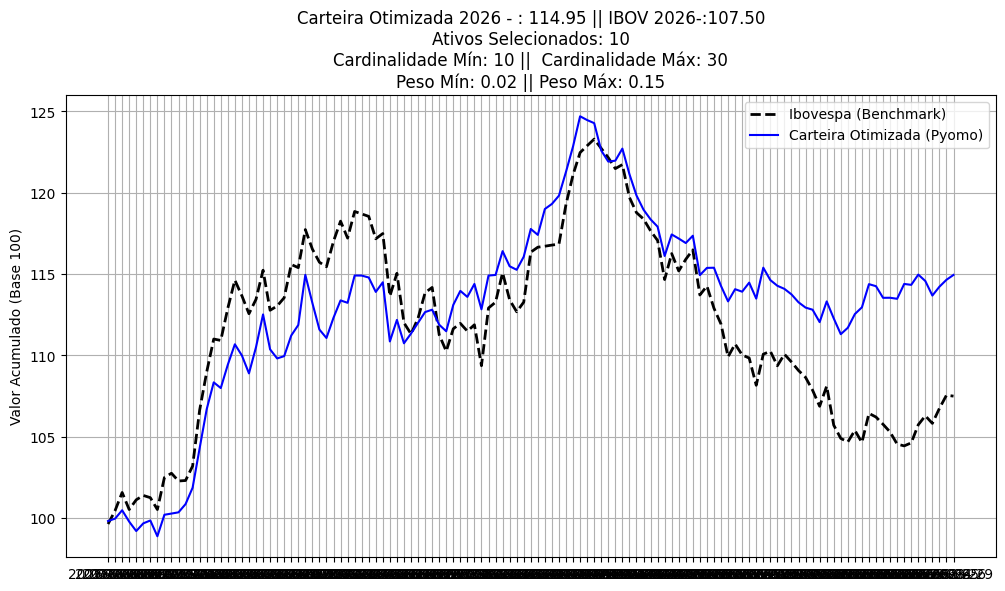

In [63]:
df_final = final[final['ativado']!=0]
print(df_final.head(20))
ativos_selecionados = df_final.index
retornos_carteira= df_plot_2026[ativos_selecionados]
# print(retornos_carteira)
carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada
# print(carteira_otimizada)
# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100

# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov = (1 + df_ibov_2026['IBOV']).cumprod() * 100

print(acum_otimizado.tail(1).values[0])
# print(acum_otimizado[-1])
# print(acum_equi[-1])
# print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada 2026 - : {acum_otimizado.tail(1).values[0]:.2f} || IBOV 2026-:{acum_ibov.tail(1).values[0]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nCardinalidade Mín: {vb_cardinalidade_min} ||  Cardinalidade Máx: {vb_cardinalidade_max}\nPeso Mín: {vb_peso_minimo} || Peso Máx: {vb_peso_maximo}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()